In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import random

In [5]:
SOURCE_DIR = Path('../data/places365_raw/train_samples')
OUTPUT_DIR = Path('../data/processed/places365')
NUM_IMAGES = 5000
TARGET_SIZE = (128, 128)

In [6]:
color_dir = OUTPUT_DIR / 'color'
gray_dir = OUTPUT_DIR / 'gray'

# Создаём папки (exist_ok=True не вызовет ошибку если папки уже существуют)
color_dir.mkdir(parents=True, exist_ok=True)
gray_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Папки созданы:")
print(f"   Цветные: {color_dir}")
print(f"   Ч/Б: {gray_dir}")

✅ Папки созданы:
   Цветные: ..\data\processed\places365\color
   Ч/Б: ..\data\processed\places365\gray


In [7]:
all_images = list(SOURCE_DIR.glob('*.jpg'))
print(f"Найдено всего фото: {len(all_images)}")

# Выбираем случайные NUM_IMAGES штук
selected_images = random.sample(all_images, min(NUM_IMAGES, len(all_images)))
print(f"Берём {len(selected_images)} фото для обработки")

Найдено всего фото: 21900
Берём 5000 фото для обработки


In [8]:
print(f"Создаю {len(selected_images)} пар изображений {TARGET_SIZE[0]}×{TARGET_SIZE[1]}...")

for idx, img_path in enumerate(selected_images):
    try:
        # Открываем цветное фото
        color_img = Image.open(img_path).convert('RGB')

        # Ресайз
        color_img_resized = color_img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

        # Сохраняем цветное
        color_path = color_dir / f'{idx:05d}.png'
        color_img_resized.save(color_path)

        # Создаём и сохраняем ч/б
        gray_img = color_img_resized.convert('L')
        gray_path = gray_dir / f'{idx:05d}.png'
        gray_img.save(gray_path)

        # Прогресс
        if (idx + 1) % 500 == 0:
            print(f"   Обработано: {idx + 1}/{len(selected_images)}")

    except Exception as e:
        print(f"Ошибка с файлом {img_path.name}: {e}")

print(f"✅ Готово! Обработано {len(selected_images)} пар")

Создаю 5000 пар изображений 128×128...
   Обработано: 500/5000
   Обработано: 1000/5000
   Обработано: 1500/5000
   Обработано: 2000/5000
   Обработано: 2500/5000
   Обработано: 3000/5000
   Обработано: 3500/5000
   Обработано: 4000/5000
   Обработано: 4500/5000
   Обработано: 5000/5000
✅ Готово! Обработано 5000 пар


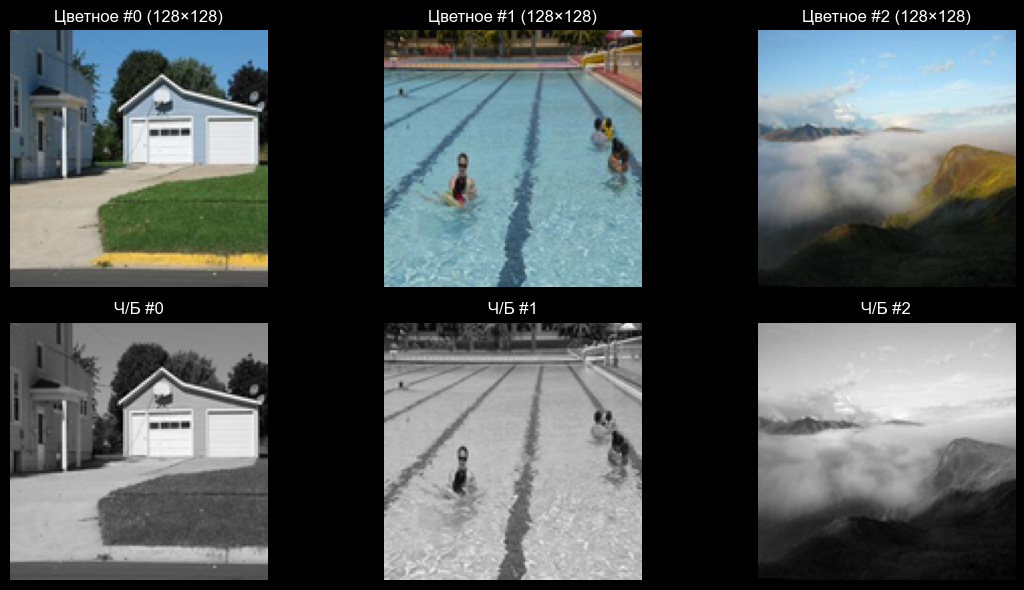

In [9]:
num_to_display = 3
fig, axes = plt.subplots(2, num_to_display, figsize=(12, 6))

for i in range(num_to_display):
    filename = f'{i:05d}.png'

    color_path = color_dir / filename
    color_img = Image.open(color_path)

    gray_path = gray_dir / filename
    gray_img = Image.open(gray_path)

    axes[0, i].imshow(color_img)
    axes[0, i].set_title(f'Цветное #{i} ({TARGET_SIZE[0]}×{TARGET_SIZE[1]})')
    axes[0, i].axis('off')

    axes[1, i].imshow(gray_img, cmap='gray')
    axes[1, i].set_title(f'Ч/Б #{i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
color_files = sorted([f.name for f in color_dir.iterdir() if f.is_file()])
gray_files = sorted([f.name for f in gray_dir.iterdir() if f.is_file()])

print(f"📊 Файлов в color/: {len(color_files)}")
print(f"📊 Файлов в gray/: {len(gray_files)}")

if set(color_files) == set(gray_files):
    print("✅ Имена файлов совпадают")
else:
    print("❌ Имена файлов НЕ совпадают")

📊 Файлов в color/: 5000
📊 Файлов в gray/: 5000
✅ Имена файлов совпадают


## Выводы

✅ Places365 успешно загружен и подготовлен для задачи колоризации

✅ Данные готовы для обучения нейросетевой модели